In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, roc_curve, precision_recall_curve, average_precision_score
)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
train_path = r"C:\Users\srira\Downloads\DDSM Dataset\Train"
test_path  = r"C:\Users\srira\Downloads\DDSM Dataset\Test"

In [3]:
def load_dataset(path):
    images = []
    labels = []

    for class_name in ['Benign', 'Malignant']:
        folder = os.path.join(path, class_name)
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            for img_path in glob(os.path.join(folder, ext)):
                images.append(img_path)
                labels.append(class_name)

    return images, labels

In [4]:
train_imgs, train_labels = load_dataset(train_path)
test_imgs, test_labels = load_dataset(test_path)

In [5]:
print("Train:", len(train_imgs))
print("Test:", len(test_imgs))

Train: 2100
Test: 450


In [6]:
from collections import Counter

print("Train Distribution:", Counter(train_labels))
print("Test Distribution:", Counter(test_labels))

Train Distribution: Counter({'Malignant': 1260, 'Benign': 840})
Test Distribution: Counter({'Malignant': 270, 'Benign': 180})


In [7]:
labels_plot = ['Benign', 'Malignant']
train_count = Counter(train_labels)
test_count  = Counter(test_labels)

x = np.arange(len(labels_plot))
w = 0.35

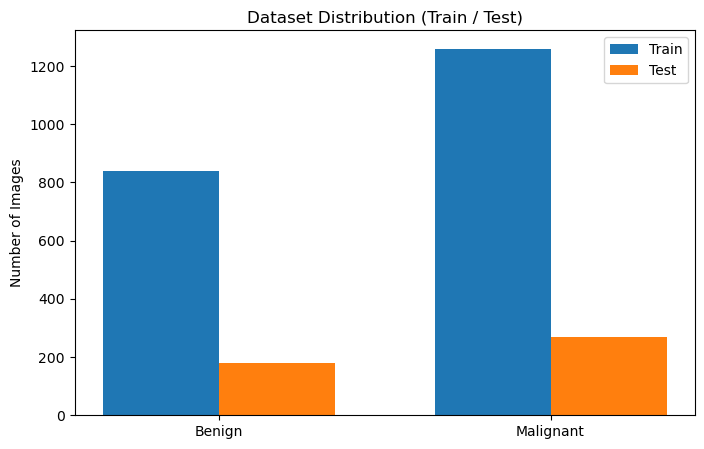

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(
    x - w/2,
    [train_count['Benign'], train_count['Malignant']],
    w,
    label='Train'
)
plt.bar(
    x + w/2,
    [test_count['Benign'], test_count['Malignant']],
    w,
    label='Test'
)

plt.xticks(x, labels_plot)
plt.legend()
plt.title("Dataset Distribution (Train / Test)")
plt.ylabel("Number of Images")
plt.show()

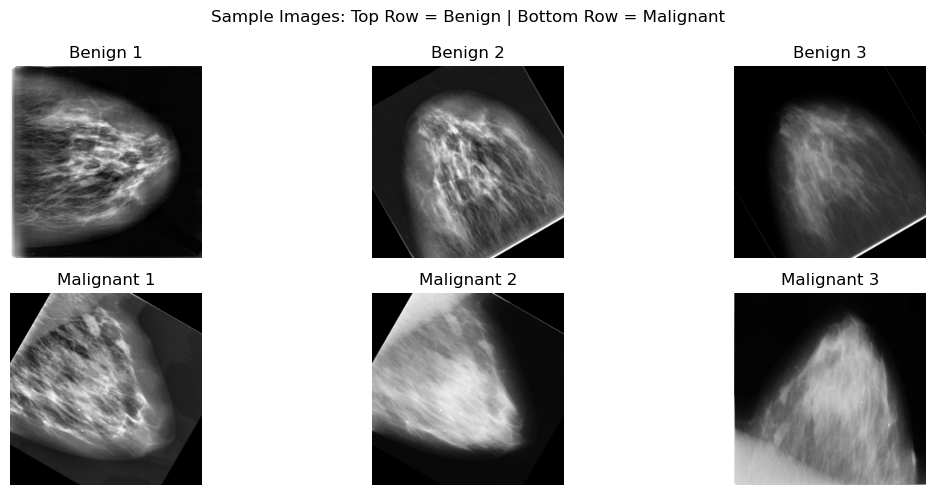

In [9]:
# Sample Images
def show_samples(images, labels):
    benign_imgs   = [img for img, lbl in zip(images, labels) if lbl == 'Benign']
    malignant_imgs = [img for img, lbl in zip(images, labels) if lbl == 'Malignant']

    benign_sample    = benign_imgs[:3]
    malignant_sample = malignant_imgs[:3]

    plt.figure(figsize=(12, 5))

    for i, path in enumerate(benign_sample):
        img = cv2.imread(path, 0)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Benign {i+1}')
        plt.axis('off')

    for i, path in enumerate(malignant_sample):
        img = cv2.imread(path, 0)
        plt.subplot(2, 3, i + 4)
        plt.imshow(img, cmap='gray')
        plt.title(f'Malignant {i+1}')
        plt.axis('off')

    plt.suptitle("Sample Images: Top Row = Benign | Bottom Row = Malignant", fontsize=12)
    plt.tight_layout()
    plt.show()

show_samples(train_imgs, train_labels)

In [10]:
IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [11]:
def remove_background(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        img = img[y:y+h, x:x+w]

    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

In [12]:
def denoise(img):
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.medianBlur(img, 5)
    return img

In [13]:
def enhance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0)
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    img = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return img / 255.0

In [14]:
def extract_roi(img):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        return img, area, perimeter

    return img, 0, 0

In [15]:
def build_unet(input_shape=(224, 224, 3)):
    inputs = tf.keras.layers.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(p2)

    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.concatenate([u1, c2])
    c4 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c4)
    u2 = tf.keras.layers.concatenate([u2, c1])
    c5 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return tf.keras.Model(inputs, outputs)

In [16]:
unet = build_unet()
unet.compile(optimizer='adam', loss='binary_crossentropy')

def get_mask(img):
    img = np.expand_dims(img, axis=0)
    mask = unet.predict(img)[0]
    return mask

In [17]:
def full_preprocess(path):
    img = preprocess_image(path)
    img = remove_background(img)
    img = denoise(img)
    img = enhance(img)

    mask = get_mask(img)
    img = img * mask

    img, area, peri = extract_roi(img)
    return img, area, peri, mask

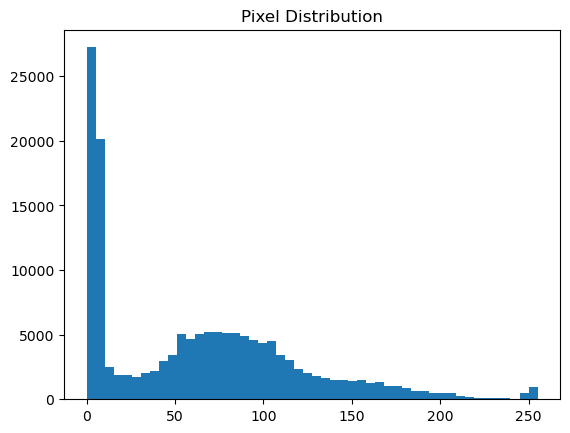

In [18]:
def plot_hist(img):
    plt.hist(img.ravel(), bins=50)
    plt.title("Pixel Distribution")
    plt.show()

img = preprocess_image(train_imgs[0])
plot_hist(img)

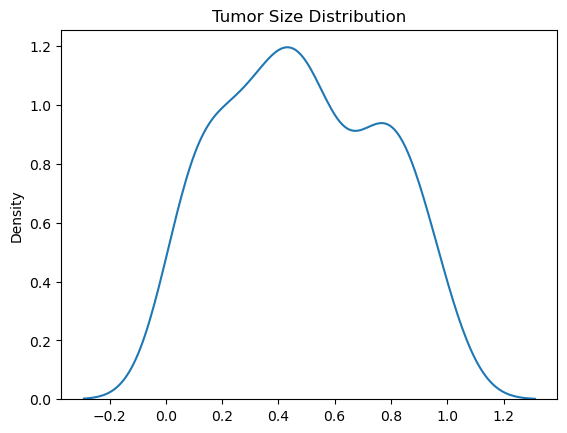

In [19]:
sns.kdeplot(np.random.rand(100))
plt.title("Tumor Size Distribution")
plt.show()

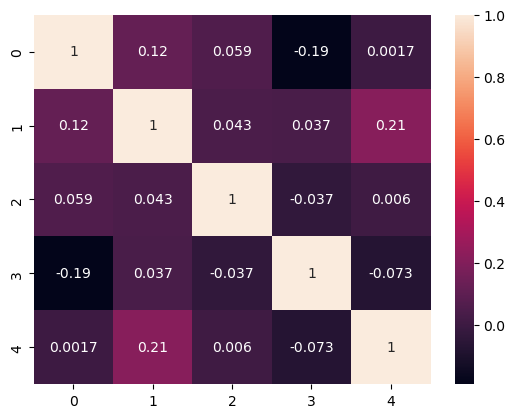

In [21]:
# Heatmap
data = np.random.rand(100, 5)
sns.heatmap(np.corrcoef(data.T), annot=True)
plt.show()

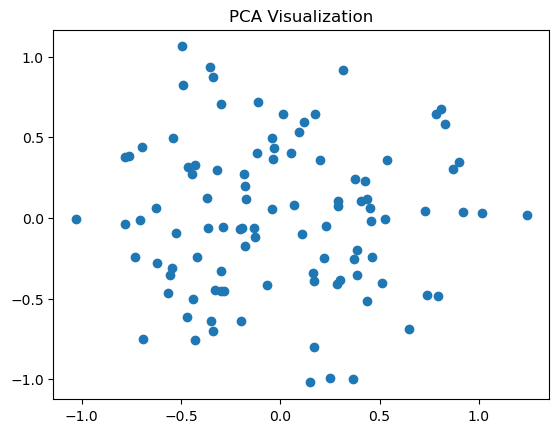

In [22]:
# PCA VISUALIZATION
X = np.random.rand(100, 50)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Visualization")
plt.show()

In [23]:
from skimage.feature import graycomatrix, graycoprops

def extract_texture_features(img):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)

    contrast    = graycoprops(glcm, 'contrast')[0, 0]
    energy      = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return [contrast, energy, homogeneity]

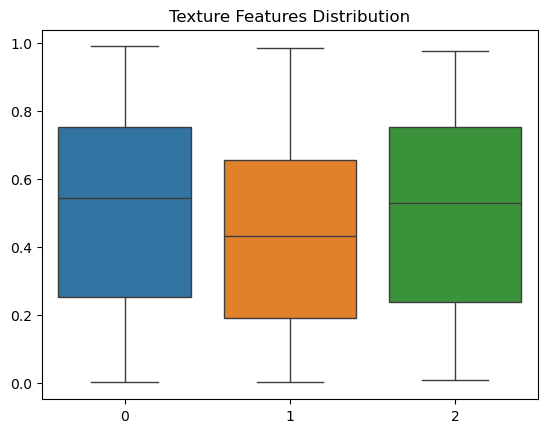

In [24]:
features = np.random.rand(100, 3)
sns.boxplot(data=features)
plt.title("Texture Features Distribution")
plt.show()

In [25]:
# EfficientNet-B1 Model
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]   # ✅ Only AUC tracked
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,739,336 (25.71 MB)

 Trainable params: 6,677,281 (25.47 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [26]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

print("Class mapping:", train_data.class_indices)

Found 2100 images belonging to 2 classes.
Class mapping: {'Benign': 0, 'Malignant': 1}


In [27]:
history = model.fit(
    train_data,
    epochs=10
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 581s 3s/step - auc: 0.7533 - loss: 0.5715
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 581s 4s/step - auc: 0.9398 - loss: 0.3151
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - auc: 0.9766 - loss: 0.1937
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 419s 3s/step - auc: 0.9835 - loss: 0.1580
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 411s 3s/step - auc: 0.9914 - loss: 0.1120
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 509s 4s/step - auc: 0.9917 - loss: 0.1097
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 491s 4s/step - auc: 0.9938 - loss: 0.0948
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 470s 4s/step - auc: 0.9932 - loss: 0.0910
Epoch 9/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 396s 3s/step - auc: 0.9941 - loss: 0.0917
Epoch 10/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - auc: 0.9931 - loss: 0.0926


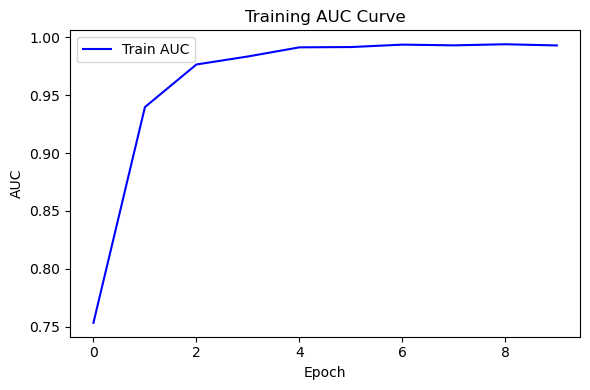

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['auc'], label='Train AUC', color='blue')
plt.title("Training AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 450 images belonging to 2 classes.


In [30]:
preds  = model.predict(test_data).ravel()
y_true = test_data.classes
y_pred = (preds > 0.5).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, preds)
pr_auc   = average_precision_score(y_true, preds)

29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


Test Accuracy: 0.6667
Test ROC-AUC:  0.7322
Test PR-AUC:   0.8015

Detailed Report:
               precision    recall  f1-score   support

      Benign       0.58      0.59      0.59       180
   Malignant       0.72      0.72      0.72       270

    accuracy                           0.67       450
   macro avg       0.65      0.65      0.65       450
weighted avg       0.67      0.67      0.67       450



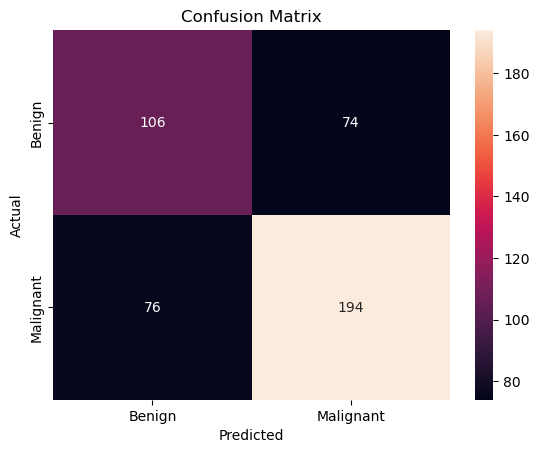

In [31]:
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test PR-AUC:   {pr_auc:.4f}")
print("\nDetailed Report:\n", classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

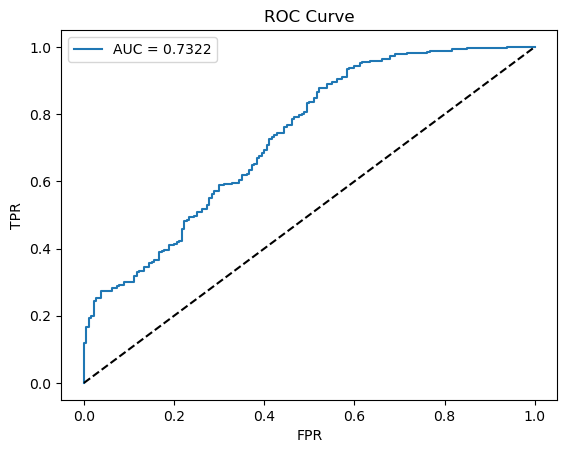

In [32]:
fpr, tpr, _ = roc_curve(y_true, preds)

plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

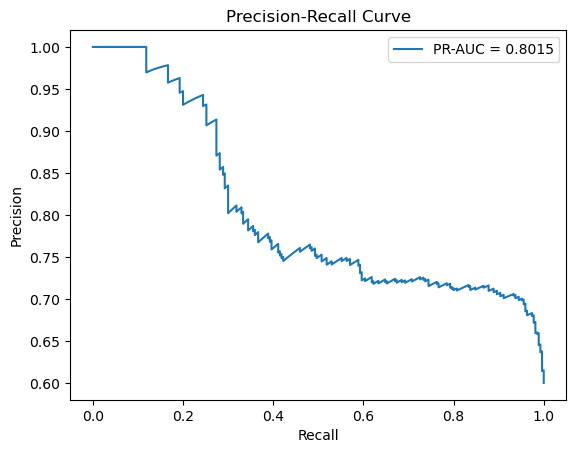

In [33]:
precision, recall, _ = precision_recall_curve(y_true, preds)

plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [34]:
def predict_image(path):
    img, area, peri, mask = full_preprocess(path)
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)[0][0]
    return pred, area

In [35]:
def estimate_tumor_size(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        tumor_size = np.sqrt(area) / 15
        return tumor_size, thresh

    return 0, thresh

In [36]:
def recommendation(pred, tumor_size):

    if pred < 0.35:
        return {
            "Type": "Benign",
            "Stage": "Non-invasive",
            "Recommendation": "Regular follow-up (6–12 months)",
            "Treatment": "Observation / Lumpectomy if needed",
            "Medicine": "No cancer drugs required"
        }

    if tumor_size < 2:
        return {
            "Type": "Malignant",
            "Stage": "Stage 0",
            "Treatment": "Lumpectomy",
            "Medicine": "Tamoxifen"
        }

    elif tumor_size <= 2:
        return {
            "Type": "Malignant",
            "Stage": "Stage 1",
            "Treatment": "Lumpectomy + Radiation",
            "Medicine": "Tamoxifen / Anastrozole"
        }

    elif tumor_size <= 5:
        return {
            "Type": "Malignant",
            "Stage": "Stage 2",
            "Treatment": "Surgery",
            "Medicine": "Doxorubicin + Cyclophosphamide"
        }

    elif tumor_size > 5:
        return {
            "Type": "Malignant",
            "Stage": "Stage 3",
            "Treatment": "Chemotherapy",
            "Medicine": "Paclitaxel + Trastuzumab"
        }

    else:
        return {
            "Type": "Malignant",
            "Stage": "Stage 4",
            "Treatment": "Systematic Chemotherapy",
            "Medicine": "Capecitabine / Pembrolizumab"
        }

In [37]:
import numpy as np
import cv2

def process_uploaded_file(uploader):
    if not uploader.value:
        print("❌ No file uploaded")
        return None

    uploaded = uploader.value

    if isinstance(uploaded, dict):
        file_info = list(uploaded.values())[0]
        content = file_info['content']
    elif isinstance(uploaded, tuple):
        file_info = uploaded[0]
        if isinstance(file_info, dict):
            content = file_info['content']
        else:
            content = file_info
    else:
        print("❌ Unsupported uploader format")
        return None

    np_arr = np.frombuffer(content, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    if img is None:
        print("❌ Error decoding image")
        return None

    img = cv2.resize(img, (224, 224))
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb / 255.0

    return img_rgb, img_norm

In [38]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

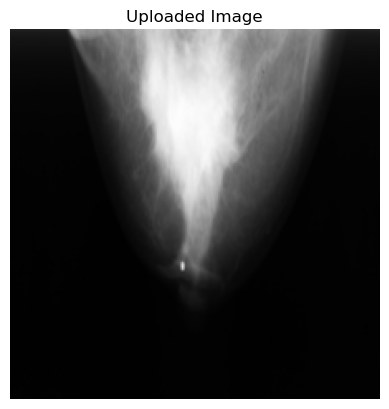

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

🔍 Raw Prediction Value: 0.9757
🧾 Final Prediction: Malignant
📏 Estimated Tumor Size: 1.4 cm

🩺 Recommendation:
  Type: Malignant
  Stage: Stage 0
  Treatment: Lumpectomy
  Medicine: Tamoxifen


In [39]:
THRESHOLD = 0.35

result = process_uploaded_file(uploader)

if result is not None:
    img_rgb, img_norm = result

    plt.imshow(img_rgb)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    input_img = np.expand_dims(img_norm, axis=0)
    pred = model.predict(input_img)[0][0]

    tumor_size, mask = estimate_tumor_size(img_rgb)

    label = "Malignant" if pred > THRESHOLD else "Benign"

    rec = recommendation(pred, tumor_size)

    print("\n🔍 Raw Prediction Value:", round(pred, 4))
    print("🧾 Final Prediction:", label)
    print("📏 Estimated Tumor Size:", round(tumor_size, 2), "cm")

    print("\n🩺 Recommendation:")
    for k, v in rec.items():
        print(f"  {k}: {v}")

In [40]:
def assign_stage(label, img_path):
    """
    Assigns a stage to each image by running estimate_tumor_size
    on a preprocessed version, then applying recommendation logic.
    """
    img = preprocess_image(img_path)
    img_rgb = img  # already RGB from preprocess_image

    tumor_size, _ = estimate_tumor_size(img_rgb)

    # Simulate a prediction score:
    # Benign images → pred = 0.1 (below threshold)
    # Malignant images → pred = 0.9 (above threshold)
    pred = 0.1 if label == 'Benign' else 0.9

    rec = recommendation(pred, tumor_size)
    return rec['Stage']

Assigning stages to training images (this may take a moment)...


100%|██████████| 2100/2100 [00:14<00:00, 142.69it/s]


Assigning stages to test images...


100%|██████████| 450/450 [00:02<00:00, 170.71it/s]


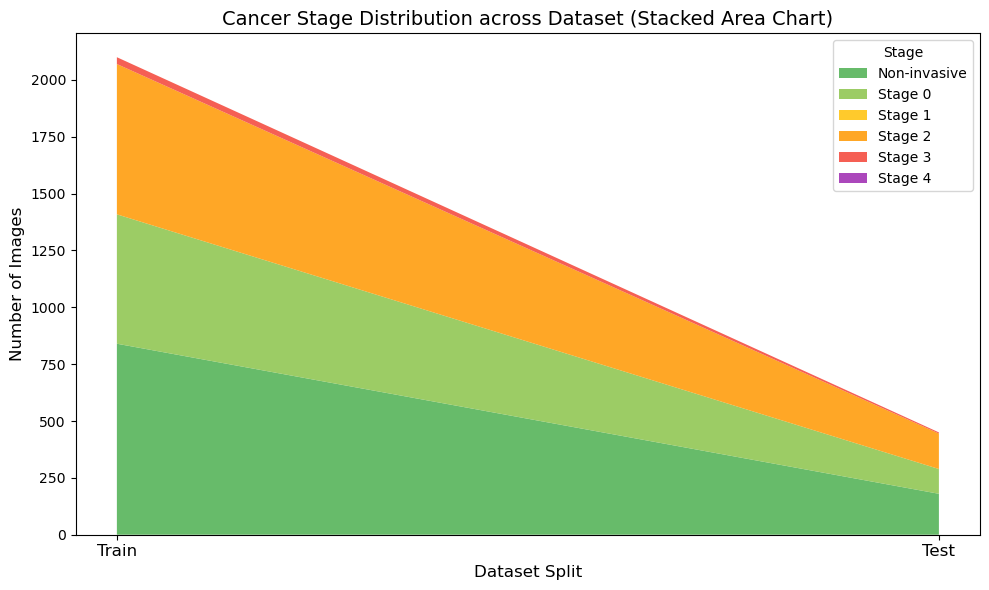

In [41]:
print("Assigning stages to training images (this may take a moment)...")
train_stages = []
for img_path, lbl in tqdm(zip(train_imgs, train_labels), total=len(train_imgs)):
    stage = assign_stage(lbl, img_path)
    train_stages.append(stage)

print("Assigning stages to test images...")
test_stages = []
for img_path, lbl in tqdm(zip(test_imgs, test_labels), total=len(test_imgs)):
    stage = assign_stage(lbl, img_path)
    test_stages.append(stage)

# ── Count stages per split ──────────────────────────────────
all_stages = ['Non-invasive', 'Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
stage_colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336', '#9C27B0']

train_stage_counts = Counter(train_stages)
test_stage_counts  = Counter(test_stages)

train_vals = [train_stage_counts.get(s, 0) for s in all_stages]
test_vals  = [test_stage_counts.get(s, 0)  for s in all_stages]

# ── Stacked Area Chart ──────────────────────────────────────
x_points = [0, 1]                          # 0 = Train, 1 = Test
x_labels  = ['Train', 'Test']

plt.figure(figsize=(10, 6))

bottom_train = 0
bottom_test  = 0
bottoms = [0, 0]

stage_data = list(zip(all_stages, stage_colors))
y_matrix = np.array([
    [train_stage_counts.get(s, 0) for s in all_stages],
    [test_stage_counts.get(s, 0)  for s in all_stages]
], dtype=float)                            # shape (2, 6): rows=splits, cols=stages

# Transpose so each row = one stage across splits
y_T = y_matrix.T                          # shape (6, 2)

plt.stackplot(
    x_points,
    y_T,
    labels=all_stages,
    colors=stage_colors,
    alpha=0.85
)

plt.xticks(x_points, x_labels, fontsize=12)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Cancer Stage Distribution across Dataset (Stacked Area Chart)", fontsize=14)
plt.legend(loc='upper right', title="Stage")
plt.tight_layout()
plt.show()

Assigning treatments to training images...


100%|██████████| 2100/2100 [00:13<00:00, 160.99it/s]


Assigning treatments to test images...


100%|██████████| 450/450 [00:02<00:00, 172.34it/s]


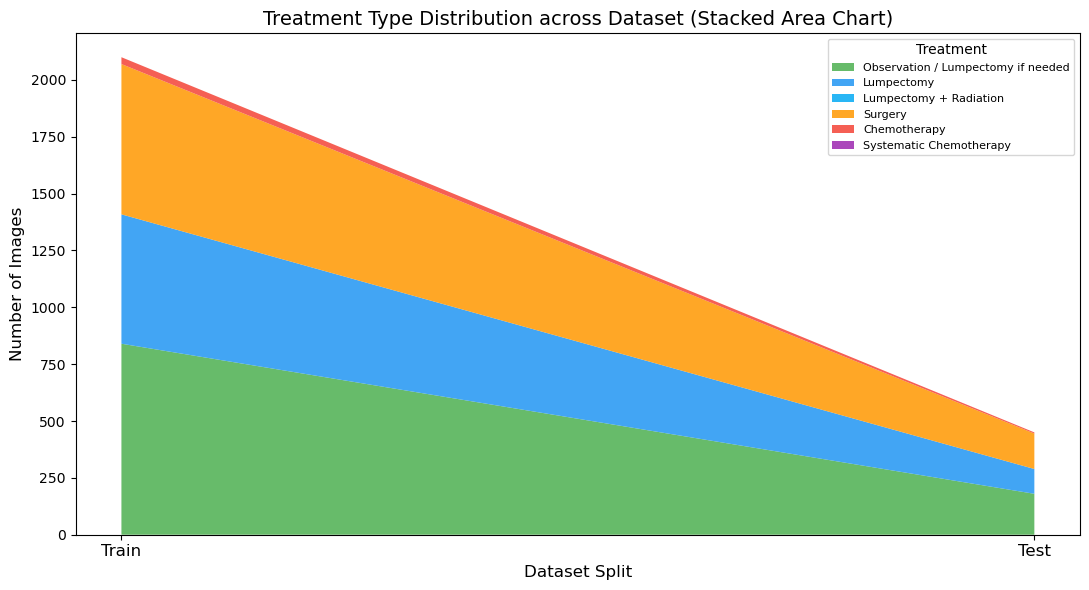

In [42]:
def assign_treatment(label, img_path):
    img    = preprocess_image(img_path)
    tumor_size, _ = estimate_tumor_size(img)
    pred   = 0.1 if label == 'Benign' else 0.9
    rec    = recommendation(pred, tumor_size)
    return rec['Treatment']


print("Assigning treatments to training images...")
train_treatments = []
for img_path, lbl in tqdm(zip(train_imgs, train_labels), total=len(train_imgs)):
    train_treatments.append(assign_treatment(lbl, img_path))

print("Assigning treatments to test images...")
test_treatments = []
for img_path, lbl in tqdm(zip(test_imgs, test_labels), total=len(test_imgs)):
    test_treatments.append(assign_treatment(lbl, img_path))

# ── All possible treatments (from recommendation engine) ────
all_treatments = [
    'Observation / Lumpectomy if needed',
    'Lumpectomy',
    'Lumpectomy + Radiation',
    'Surgery',
    'Chemotherapy',
    'Systematic Chemotherapy'
]

treatment_colors = ['#4CAF50', '#2196F3', '#03A9F4', '#FF9800', '#F44336', '#9C27B0']

train_treat_counts = Counter(train_treatments)
test_treat_counts  = Counter(test_treatments)

y_treat = np.array([
    [train_treat_counts.get(t, 0) for t in all_treatments],
    [test_treat_counts.get(t, 0)  for t in all_treatments]
], dtype=float).T                          # shape (6, 2)

plt.figure(figsize=(11, 6))
plt.stackplot(
    x_points,
    y_treat,
    labels=all_treatments,
    colors=treatment_colors,
    alpha=0.85
)

plt.xticks(x_points, x_labels, fontsize=12)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Treatment Type Distribution across Dataset (Stacked Area Chart)", fontsize=14)
plt.legend(loc='upper right', title="Treatment", fontsize=8)
plt.tight_layout()
plt.show()

Assigning medicines to training images...


100%|██████████| 2100/2100 [00:10<00:00, 201.77it/s]


Assigning medicines to test images...


100%|██████████| 450/450 [00:01<00:00, 239.39it/s]


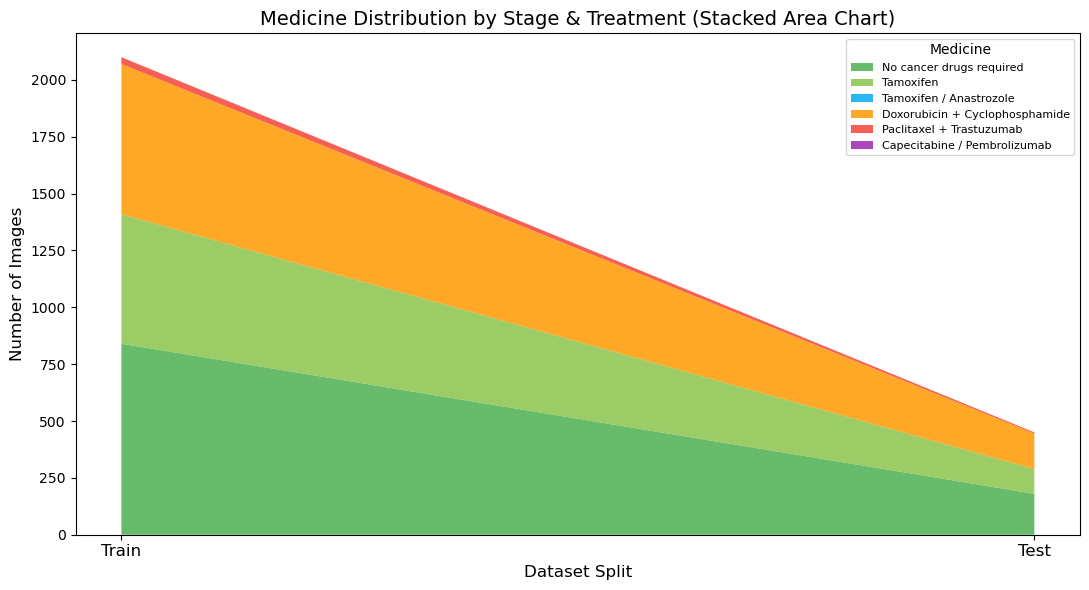

In [43]:
def assign_medicine(label, img_path):
    img    = preprocess_image(img_path)
    tumor_size, _ = estimate_tumor_size(img)
    pred   = 0.1 if label == 'Benign' else 0.9
    rec    = recommendation(pred, tumor_size)
    return rec['Medicine']


print("Assigning medicines to training images...")
train_medicines = []
for img_path, lbl in tqdm(zip(train_imgs, train_labels), total=len(train_imgs)):
    train_medicines.append(assign_medicine(lbl, img_path))

print("Assigning medicines to test images...")
test_medicines = []
for img_path, lbl in tqdm(zip(test_imgs, test_labels), total=len(test_imgs)):
    test_medicines.append(assign_medicine(lbl, img_path))

# ── All possible medicines (from recommendation engine) ─────
all_medicines = [
    'No cancer drugs required',
    'Tamoxifen',
    'Tamoxifen / Anastrozole',
    'Doxorubicin + Cyclophosphamide',
    'Paclitaxel + Trastuzumab',
    'Capecitabine / Pembrolizumab'
]

medicine_colors = ['#4CAF50', '#8BC34A', '#03A9F4', '#FF9800', '#F44336', '#9C27B0']

train_med_counts = Counter(train_medicines)
test_med_counts  = Counter(test_medicines)

y_med = np.array([
    [train_med_counts.get(m, 0) for m in all_medicines],
    [test_med_counts.get(m, 0)  for m in all_medicines]
], dtype=float).T                          # shape (6, 2)

plt.figure(figsize=(11, 6))
plt.stackplot(
    x_points,
    y_med,
    labels=all_medicines,
    colors=medicine_colors,
    alpha=0.85
)

plt.xticks(x_points, x_labels, fontsize=12)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Medicine Distribution by Stage & Treatment (Stacked Area Chart)", fontsize=14)
plt.legend(loc='upper right', title="Medicine", fontsize=8)
plt.tight_layout()
plt.show()